# Single-cell inference

Load a folder of brightfield images, plot sample predictions, and optionally save all predictions with metrics to a folder.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import sys, os
os.environ.setdefault("OPENCV_LOG_LEVEL", "ERROR")
import cv2
try:
    cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)
except AttributeError:
    pass
cwd = os.getcwd()
S2F_ROOT = cwd if os.path.exists(os.path.join(cwd, 'models')) else os.path.dirname(cwd)
sys.path.insert(0, S2F_ROOT)
import torch
from data.cell_dataset import load_brightfield_loader
from models.s2f_model import create_s2f_model
from utils.substrate_settings import compute_settings_normalization
from utils.inference import plot_inference_samples, save_all_predictions

## 1. Config

In [ ]:
CHECKPOINT_PATH = os.path.join(S2F_ROOT, 'ckp', 'single_cell', 'ckp_singlecell_GN.pth')
INFERENCE_FOLDER = os.path.normpath(os.path.join(S2F_ROOT, 'S2FApp', 'samples')) #the folder path with brightfield images
IMAGE_SIZE = 1024
BATCH_SIZE = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SUBSTRATE = 'fibroblasts_PDMS'
CONFIG_PATH = os.path.join(S2F_ROOT, 'config', 'substrate_settings.json')
norm_params = compute_settings_normalization(config_path=CONFIG_PATH)

## 2. Load model

In [8]:
generator, _ = create_s2f_model(in_channels=3, model_type='s2f')
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
generator.load_state_dict(checkpoint.get('generator_state_dict'), strict=True)
generator = generator.to(DEVICE)
_ = generator.eval()

## 3. Inference

Loaded 5 images


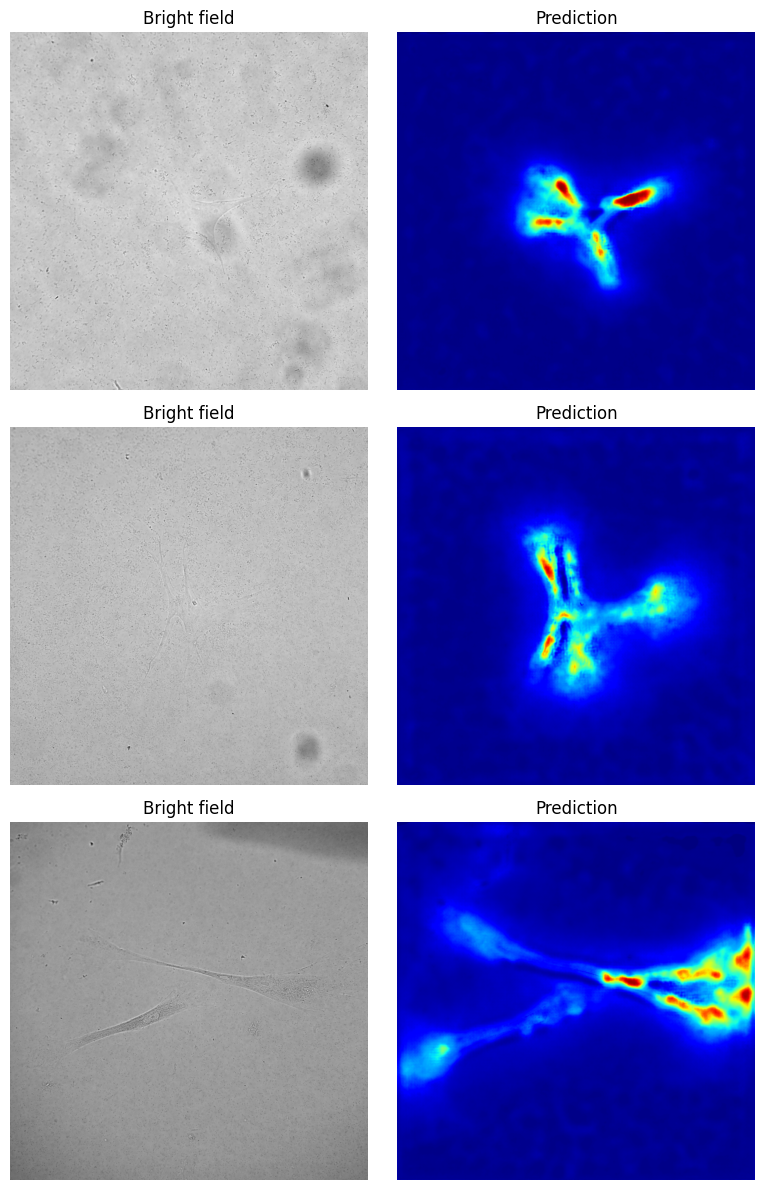

In [9]:
loader = load_brightfield_loader(INFERENCE_FOLDER, img_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
print(f"Loaded {len(loader.dataset)} images")

plot_inference_samples(loader, generator, n_samples=3, device=DEVICE, substrate=SUBSTRATE,
                        normalization_params=norm_params, config_path=CONFIG_PATH)

In [ ]:
SAVE_PREDICTION_PATH = "" # os.path.join(S2F_ROOT, 'predictions')
if SAVE_PREDICTION_PATH:
    save_all_predictions(loader, generator, SAVE_PREDICTION_PATH, device=DEVICE, substrate=SUBSTRATE,
                            normalization_params=norm_params, config_path=CONFIG_PATH)